# 05. Covariate Balance Diagnostics

Observational causal inference should not jump from a treatment model directly to an effect estimate. The design must earn the right to look at outcomes.

Covariate balance diagnostics answer a design question:

> After adjustment, matching, or weighting, do the treated and untreated groups look comparable on the observed pre-treatment variables that matter for the causal question?

This notebook is the diagnostics workbench for the observational-adjustment module. We will build reusable balance tools, apply them to raw, matched, and weighted designs, and learn how to decide whether a design is ready for outcome analysis.

## Learning Goals

By the end of this notebook, you should be able to:

- Explain why balance diagnostics belong before outcome analysis.
- Compute standardized mean differences for unweighted and weighted designs.
- Build a love plot for raw, matched, and weighted comparisons.
- Diagnose balance for continuous, binary, categorical, transformed, and interaction covariates.
- Explain why p-values are not a good primary balance diagnostic.
- Use distributional diagnostics such as weighted ECDF gaps, quantile differences, and histograms.
- Distinguish balance on confounders from balance on pure treatment predictors.
- Summarize whether a design is ready for outcome analysis.

## Mathematical Setup: Balance as a Design Diagnostic

Balance diagnostics ask whether treated and comparison units look similar on pre-treatment covariates after a design step such as matching, weighting, or trimming. For a numeric covariate $X$, the unweighted standardized mean difference is:

$$
SMD(X) = \frac{\bar{X}_{1} - \bar{X}_{0}}{\sqrt{(s_1^2+s_0^2)/2}}
$$

With observation weights $w_i$, use weighted means:

$$
\bar{X}_{a,w} = \frac{\sum_{i:A_i=a}w_iX_i}{\sum_{i:A_i=a}w_i}
$$

A weighted SMD replaces the unweighted means and variances with weighted versions. A second useful check is the variance ratio:

$$
VR(X) = \frac{s_1^2}{s_0^2}
$$

Good balance shows that the observed design problem has become more credible before the outcome is analyzed. Unmeasured confounding remains a separate assumption.

In [1]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
from pathlib import Path
import sys


def _find_project_root(start=Path.cwd()):
    """
    Locate the portfolio project root so shared notebook utilities can be imported.
    
    Idea:
        The notebooks may be executed from different working directories, so this helper walks upward until it finds the repository structure used by the lecture series.
    
    Args:
        start: Directory where the upward search for the project root begins.
    
    Returns:
        pathlib.Path: Absolute path to the portfolio project root.
    """

    for candidate in [start, *start.parents]:
        if (candidate / "notebooks" / "_shared").exists():
            return candidate
    return start


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy import stats
from scipy.special import expit
from sklearn.neighbors import NearestNeighbors
from graphviz import Digraph
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.precision", 3)

from notebooks._shared.display import smart_display

In [2]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    """
    Create a styled Graphviz causal or design diagram for the lecture.
    
    Idea:
        The diagram makes assumptions, assignment mechanisms, and diagnostic workflows visible before the code estimates an effect.
    
    Args:
        edges: Directed edges from source node to target node in the causal or design diagram.
        title: Title displayed on the Graphviz or Matplotlib figure.
        node_colors: Optional mapping from node labels to fill colors.
        rankdir: Graphviz layout direction, such as left-to-right or top-to-bottom.
    
    Returns:
        graphviz.Digraph: Renderable diagram object for display in the notebook.
    """
    node_colors = node_colors or {}
    dot = Digraph(format="svg")
    dot.attr(rankdir=rankdir, bgcolor="transparent", pad="0.2")
    dot.attr("graph", labelloc="t", fontsize="18", fontname="DejaVu Sans")
    if title:
        dot.attr(label=title)
    dot.attr("node", shape="box", style="rounded,filled", fontname="DejaVu Sans", fontsize="11", margin="0.12,0.08", color="#334155")
    dot.attr("edge", color="#475569", arrowsize="0.8", fontname="DejaVu Sans", fontsize="10")
    for node in sorted(set([u for u, _ in edges] + [v for _, v in edges])):
        dot.node(node, fillcolor=node_colors.get(node, "#f8fafc"))
    for u, v in edges:
        dot.edge(u, v)
    return dot


def weighted_mean_and_var(x, w):
    """Compute a weighted mean and variance for balance diagnostics.

    Args:
        x: Numeric vector or covariate values used in the calculation.
        w: Weight vector used for weighted summaries.

    Returns:
        tuple: Weighted mean and weighted variance.
    """
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    mean = np.sum(w * x) / np.sum(w)
    var = np.sum(w * (x - mean) ** 2) / np.sum(w)
    return mean, var


def standardized_mean_differences(frame, covariates, treatment="treated", weights=None):
    """
    Compute standardized mean differences for pre-treatment covariates.
    
    Idea:
        SMDs put covariate imbalance on a common scale so diagnostics can be compared before and after adjustment or weighting.
    
    Args:
        frame: Analysis DataFrame containing the treatment, outcome, score, or covariate columns used by the helper.
        covariates: Pre-treatment covariate columns evaluated for balance or adjustment.
        treatment: Treatment column or treatment value used to define the causal contrast.
        weights: Optional observation weights defining the adjusted pseudo-population.
    
    Returns:
        pandas.DataFrame: Balance diagnostics for each covariate, including treated and comparison summaries.
    """
    if weights is None:
        weights = np.ones(len(frame))
    weights = np.asarray(weights, dtype=float)
    treated = frame[treatment].to_numpy() == 1
    rows = []
    for col in covariates:
        x = frame[col].to_numpy(dtype=float)
        mt, vt = weighted_mean_and_var(x[treated], weights[treated])
        mc, vc = weighted_mean_and_var(x[~treated], weights[~treated])
        pooled_sd = np.sqrt((vt + vc) / 2)
        smd = np.nan if pooled_sd == 0 else (mt - mc) / pooled_sd
        rows.append({
            "covariate": col,
            "treated_mean": mt,
            "control_mean": mc,
            "smd": smd,
            "abs_smd": abs(smd),
        })
    return pd.DataFrame(rows).sort_values("abs_smd", ascending=False)


def plot_love(balance_tables, title, threshold=0.10, figsize=None):
    """Create a Love plot comparing covariate imbalance across designs.

    Args:
        balance_tables: Collection of balance tables to compare across designs.
        title: Title shown on the resulting figure.
        threshold: Diagnostic threshold used to flag imbalance.
        figsize: Matplotlib figure size.

    Returns:
        tuple: Matplotlib figure and axes for the balance plot.
    """
    plot_df = pd.concat(
        [table.assign(design=label) for label, table in balance_tables.items()],
        ignore_index=True,
    )
    order = plot_df.groupby("covariate")["abs_smd"].max().sort_values(ascending=True).index
    if figsize is None:
        figsize = (9, max(4.5, 0.38 * len(order)))
    fig, ax = plt.subplots(figsize=figsize)
    sns.scatterplot(
        data=plot_df,
        x="smd",
        y="covariate",
        hue="design",
        style="design",
        s=80,
        ax=ax,
        zorder=3,
    )
    ax.axvline(0, color="#64748b", linewidth=1)
    ax.axvline(threshold, color="#94a3b8", linestyle="--", linewidth=1)
    ax.axvline(-threshold, color="#94a3b8", linestyle="--", linewidth=1)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order)
    ax.set_xlabel("Standardized mean difference")
    ax.set_ylabel("")
    ax.set_title(title)
    ax.legend(frameon=False, loc="lower right")
    sns.despine(ax=ax)
    plt.show()


def effective_sample_size(weights):
    """Compute Kish effective sample size from a vector of weights.

    Args:
        weights: Observation weights used to define the target pseudo-population or summary.

    Returns:
        float: Effective sample size implied by the design or weights.
    """
    weights = np.asarray(weights, dtype=float)
    return weights.sum() ** 2 / np.sum(weights ** 2)


def ate_weights(treatment, score):
    """Construct inverse-probability weights for the ATE target population.

    Args:
        treatment: Treatment indicator or treatment column name.
        score: Running variable or propensity score used by the design.

    Returns:
        numpy.ndarray: ATE inverse-probability weights.
    """
    treatment = np.asarray(treatment, dtype=float)
    score = np.asarray(score, dtype=float)
    return treatment / score + (1 - treatment) / (1 - score)


def stabilized_ate_weights(treatment, score):
    """Construct stabilized ATE weights to reduce weight volatility.

    Args:
        treatment: Treatment indicator or treatment column name.
        score: Running variable or propensity score used by the design.

    Returns:
        numpy.ndarray: Stabilized ATE weights.
    """
    treatment = np.asarray(treatment, dtype=float)
    score = np.asarray(score, dtype=float)
    p_treated = treatment.mean()
    return treatment * p_treated / score + (1 - treatment) * (1 - p_treated) / (1 - score)


def weighted_ecdf_on_grid(x, weights, grid):
    """Evaluate a weighted empirical CDF on a fixed grid.

    Args:
        x: Numeric vector or covariate values used in the calculation.
        weights: Observation weights used to define the target pseudo-population or summary.
        grid: Grid of values for evaluating a weighted empirical distribution.

    Returns:
        numpy.ndarray: Weighted empirical CDF evaluated on the grid.
    """
    x = np.asarray(x, dtype=float)
    weights = np.asarray(weights, dtype=float)
    order = np.argsort(x)
    x_sorted = x[order]
    w_sorted = weights[order]
    cdf = np.cumsum(w_sorted) / np.sum(w_sorted)
    return np.interp(grid, x_sorted, cdf, left=0.0, right=1.0)


def weighted_ks_distance(frame, covariate, treatment="treated", weights=None, grid_size=300):
    """Compute a weighted Kolmogorov-Smirnov distance for distributional balance.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.
        covariate: Covariate name being balanced, plotted, or summarized.
        treatment: Treatment indicator or treatment column name.
        weights: Observation weights used to define the target pseudo-population or summary.
        grid_size: Number of grid points for distributional balance diagnostics.

    Returns:
        float: Maximum treated-control CDF distance.
    """
    if weights is None:
        weights = np.ones(len(frame))
    weights = np.asarray(weights, dtype=float)
    treated = frame[treatment].to_numpy() == 1
    x = frame[covariate].to_numpy(dtype=float)
    grid = np.linspace(np.nanmin(x), np.nanmax(x), grid_size)
    cdf_t = weighted_ecdf_on_grid(x[treated], weights[treated], grid)
    cdf_c = weighted_ecdf_on_grid(x[~treated], weights[~treated], grid)
    return float(np.max(np.abs(cdf_t - cdf_c)))


def weighted_quantile(values, weights, quantiles):
    """Compute weighted quantiles for balance diagnostics.

    Args:
        values: Numeric values to summarize.
        weights: Observation weights used to define the target pseudo-population or summary.
        quantiles: Quantile levels to estimate under weights.

    Returns:
        numpy.ndarray: Weighted quantile values.
    """
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    quantiles = np.asarray(quantiles, dtype=float)
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cumulative = np.cumsum(weights) - 0.5 * weights
    cumulative = cumulative / np.sum(weights)
    return np.interp(quantiles, cumulative, values)


def quantile_balance(frame, covariate, treatment="treated", weights=None, quantiles=(0.1, 0.25, 0.5, 0.75, 0.9)):
    """Compare weighted quantiles between treated and comparison groups.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.
        covariate: Covariate name being balanced, plotted, or summarized.
        treatment: Treatment indicator or treatment column name.
        weights: Observation weights used to define the target pseudo-population or summary.
        quantiles: Quantile levels to estimate under weights.

    Returns:
        pandas.DataFrame: Quantile differences between treated and comparison groups.
    """
    if weights is None:
        weights = np.ones(len(frame))
    weights = np.asarray(weights, dtype=float)
    treated = frame[treatment].to_numpy() == 1
    x = frame[covariate].to_numpy(dtype=float)
    qt = weighted_quantile(x[treated], weights[treated], quantiles)
    qc = weighted_quantile(x[~treated], weights[~treated], quantiles)
    return pd.DataFrame({
        "quantile": quantiles,
        "treated": qt,
        "control": qc,
        "treated_minus_control": qt - qc,
    })


def balance_dashboard(balance_table, weights=None, threshold=0.10):
    """Summarize balance quality, maximum imbalance, and effective sample size for a design.

    Args:
        balance_table: Covariate-balance table used for diagnostics.
        weights: Observation weights used to define the target pseudo-population or summary.
        threshold: Diagnostic threshold used to flag imbalance.

    Returns:
        pandas.Series: Balance summary for a candidate design.
    """
    row = {
        "max_abs_smd": balance_table["abs_smd"].max(),
        "mean_abs_smd": balance_table["abs_smd"].mean(),
        "covariates_above_threshold": int((balance_table["abs_smd"] > threshold).sum()),
        "covariates_total": len(balance_table),
    }
    if weights is not None:
        weights = np.asarray(weights, dtype=float)
        row.update({
            "effective_sample_size": effective_sample_size(weights),
            "ess_share_of_n": effective_sample_size(weights) / len(weights),
            "max_weight": weights.max(),
            "p99_weight": np.quantile(weights, 0.99),
        })
    return row

## 1. Why Balance Comes Before Outcomes

A causal design should be evaluated without peeking at the outcome. If the design does not balance important pre-treatment covariates, the outcome estimate is hard to interpret.

Stuart (2010) describes matching as an attempt to approximate a randomized experiment by creating treated and control groups with similar covariate distributions. Austin (2009, 2011) emphasizes standardized differences and graphical displays for balance diagnostics, and notes that significance tests are poor primary diagnostics because they are tied to sample size.

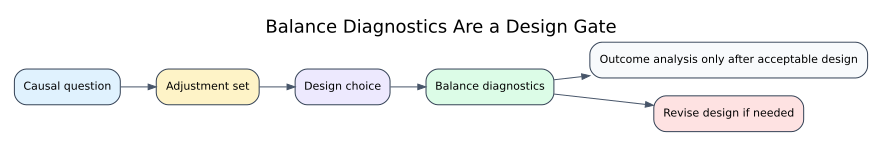

In [3]:
# Organize the calculation into readable steps for the lecture narrative.
design_edges = [
    ("Causal question", "Adjustment set"),
    ("Adjustment set", "Design choice"),
    ("Design choice", "Balance diagnostics"),
    ("Balance diagnostics", "Revise design if needed"),
    ("Balance diagnostics", "Outcome analysis only after acceptable design"),
]

colors = {
    "Causal question": "#e0f2fe",
    "Adjustment set": "#fef3c7",
    "Design choice": "#ede9fe",
    "Balance diagnostics": "#dcfce7",
    "Revise design if needed": "#fee2e2",
    "Outcome analysis only after acceptable design": "#f8fafc",
}

smart_display(make_dag(design_edges, "Balance Diagnostics Are a Design Gate", colors))

Balance diagnostics are a gate. A design can pass, fail, or pass only for a narrowed target population. The key discipline is that the gate is evaluated before the outcome estimate becomes the center of attention.

## 2. Running Example: Customer-Success Outreach

We continue the customer-success example.

A SaaS company gave proactive outreach to selected accounts. Outreach was more likely for accounts with higher risk, certain plan tiers, and available customer-success capacity. We want to know whether the adjusted design makes contacted and uncontacted accounts comparable before estimating the effect of outreach on account health.

**Dataset and experiment setup.** The balance-diagnostics example uses the same kind of targeted outreach problem as the surrounding adjustment notebooks. The units are customers, the treatment is outreach, and the outcome is deliberately kept in the background while designs are evaluated. That is intentional. In observational causal work, balance diagnostics should be reviewed before leaning on outcome estimates. The simulated covariates include risk, account value, tenure, usage, and support burden so the notebook can show mean balance, distributional balance, and outcome-relevant imbalance in a business-like setting.

In [4]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def simulate_customer_success(n=8000, seed=5055):
    """Generate an observational customer-success outreach dataset with measured confounding.

    Args:
        n: Number of simulated units.
        seed: Random seed for reproducible simulation or resampling.

    Returns:
        pandas.DataFrame: Simulated dataset with observed variables and any known truth columns used for teaching.
    """
    rng = np.random.default_rng(seed)

    plan = rng.choice(["startup", "growth", "enterprise"], p=[0.42, 0.38, 0.20], size=n)
    plan_effect = pd.Series(plan).map({"startup": 0.0, "growth": 3.0, "enterprise": 7.0}).to_numpy()

    tenure = np.clip(rng.gamma(shape=2.2, scale=7.0, size=n), 1, 48)
    usage = np.clip(rng.normal(50 + 0.6 * tenure + 2.0 * plan_effect, 12, n), 5, 120)
    pre_value = np.clip(rng.normal(80 + 1.2 * tenure + 5.0 * plan_effect, 18, n), 20, 220)
    risk_score = expit(1.4 - 0.045 * usage - 0.012 * pre_value + rng.normal(0, 0.8, n))
    manager_capacity = rng.normal(0, 1, n)

    treatment_probability = expit(
        -2.1
        + 4.1 * risk_score
        + 0.45 * (plan == "enterprise")
        + 0.25 * (plan == "growth")
        - 0.008 * tenure
        + 0.75 * manager_capacity
    )
    treated = rng.binomial(1, treatment_probability)

    y0 = (
        62
        + 0.10 * pre_value
        + 0.18 * tenure
        + 0.22 * usage
        + plan_effect
        - 22 * risk_score
        + 8 * risk_score**2
        + rng.normal(0, 4.5, n)
    )

    treatment_effect = (
        3.0
        + 1.00 * (plan == "enterprise")
        + 0.45 * (plan == "growth")
        - 1.40 * risk_score
        + 0.012 * usage
    )
    outcome = y0 + treatment_effect * treated

    return pd.DataFrame({
        "plan": plan,
        "tenure": tenure,
        "usage": usage,
        "pre_value": pre_value,
        "risk_score": risk_score,
        "manager_capacity": manager_capacity,
        "true_assignment_probability": treatment_probability,
        "treated": treated,
        "outcome": outcome,
        "true_individual_effect": treatment_effect,
    })


df = simulate_customer_success()
true_ate = df["true_individual_effect"].mean()
naive_effect = df.loc[df["treated"] == 1, "outcome"].mean() - df.loc[df["treated"] == 0, "outcome"].mean()

summary = pd.DataFrame({
    "quantity": [
        "Number of accounts",
        "Share receiving outreach",
        "True ATE in simulation",
        "Naive treated-control difference",
        "Naive bias vs true ATE",
    ],
    "value": [
        len(df),
        df["treated"].mean(),
        true_ate,
        naive_effect,
        naive_effect - true_ate,
    ],
})

smart_display(summary)
smart_display(df.head())

,quantity,value
0,Number of accounts,8000.000
1,Share receiving outreach,0.190
2,True ATE in simulation,4.027
3,Naive treated-control difference,2.191
4,Naive bias vs true ATE,-1.836


,plan,tenure,usage,pre_value,risk_score,manager_capacity,true_assignment_probability,treated,outcome,true_individual_effect
0,startup,31.240,71.020,144.941,0.011,-0.767,0.053,0,93.810,3.837
1,enterprise,5.251,93.469,149.402,0.020,0.819,0.270,0,107.451,5.094
2,growth,8.649,36.836,86.795,0.166,1.084,0.395,0,79.637,3.659
3,startup,6.309,68.709,85.553,0.178,-0.864,0.112,0,89.538,3.576
4,startup,11.906,42.352,101.518,0.221,0.047,0.222,0,71.576,3.198


We know the true effect only because this is simulated. In a real project, balance diagnostics become even more important because there is no true effect column to check against.

The diagnostic workflow below should be used before trusting the outcome estimate.

## 3. Define the Balance Table

The balance table should include pre-treatment variables needed for the causal question. Here we include:

- Continuous customer variables: risk, usage, pre-period value, tenure.
- Operational assignment variable: manager capacity.
- Plan-tier indicators.

We will sometimes evaluate all variables and sometimes focus on the outcome-relevant confounders. That distinction is useful because some variables strongly predict treatment but are not causes of the outcome in this simulation.

In [5]:
# Prepare the quantities used in the Define the Balance Table discussion.
plan_dummies = pd.get_dummies(df["plan"], prefix="plan", dtype=float)
balance_frame = pd.concat(
    [
        df[["treated", "risk_score", "usage", "pre_value", "tenure", "manager_capacity"]],
        plan_dummies,
    ],
    axis=1,
)
balance_covariates = [c for c in balance_frame.columns if c != "treated"]
outcome_relevant_covariates = [c for c in balance_covariates if c != "manager_capacity"]

raw_balance = standardized_mean_differences(balance_frame, balance_covariates)
raw_confounder_balance = standardized_mean_differences(balance_frame, outcome_relevant_covariates)

smart_display(raw_balance)

,covariate,treated_mean,control_mean,smd,abs_smd
4,manager_capacity,0.555,-0.148,0.731,0.731
0,risk_score,0.115,0.081,0.337,0.337
1,usage,62.202,64.970,-0.194,0.194
3,tenure,13.970,15.649,-0.173,0.173
2,pre_value,109.061,112.011,-0.116,0.116
7,plan_startup,0.397,0.427,-0.061,0.061
5,plan_enterprise,0.226,0.206,0.049,0.049
6,plan_growth,0.377,0.367,0.020,0.020


The raw balance table already tells us that a naive comparison is not credible. Several covariates differ meaningfully between contacted and uncontacted accounts.

A balance table is not a causal proof. It is a diagnostic for observed covariates. Hidden confounding can remain even when observed balance looks good.

## 4. Standardized Mean Differences

For a continuous covariate, the standardized mean difference is:

$$
SMD = \frac{\bar{X}_{treated} - \bar{X}_{control}}{\sqrt{(s^2_{treated} + s^2_{control})/2}}
$$

For a binary covariate, the same formula applies with proportions and binomial variances. The value is unitless, so it lets us compare balance across variables measured on different scales.

Rules of thumb such as `|SMD| < 0.10` are useful, but not sacred. Important covariates may require stricter standards.

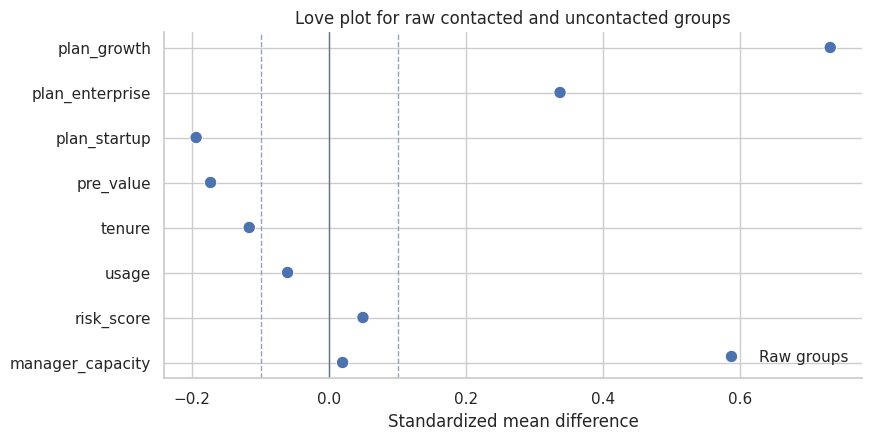

In [6]:
plot_love(
    {"Raw groups": raw_balance},
    title="Love plot for raw contacted and uncontacted groups",
)

A love plot shows SMDs for many covariates at once. The dashed lines mark a common `0.10` threshold. Treat the threshold as a guide, and use the plot to see where imbalance remains.

Variables far from zero deserve design attention before outcome analysis.

## 5. Why P-values Are Poor Balance Diagnostics

A p-value asks whether an observed difference is statistically distinguishable from zero under a sampling model. Balance diagnostics ask a design question: is the difference large enough to threaten the comparison?

Those are different questions. With large samples, tiny imbalances can be statistically significant. With small samples, meaningful imbalances may fail to reach statistical significance.

In [7]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def raw_t_test_and_smd(frame, covariate, sample_n=None, seed=7):
    """Compute raw t test and smd for 05. Covariate Balance Diagnostics.

    Args:
        frame: Analysis DataFrame to copy, transform, summarize, or model.
        covariate: Covariate being balanced, plotted, or summarized.
        sample_n: Subsample size used for a diagnostic calculation.
        seed: Random seed used for reproducibility.

    Returns:
        pandas.Series: T-test p-value and SMD for the covariate diagnostic.
    """
    work = frame.copy()
    if sample_n is not None:
        work = work.sample(sample_n, random_state=seed)
    treated = work[work["treated"] == 1][covariate]
    control = work[work["treated"] == 0][covariate]
    test = stats.ttest_ind(treated, control, equal_var=False)
    balance = standardized_mean_differences(work[["treated", covariate]], [covariate])
    return {
        "sample": "Full sample" if sample_n is None else f"Subsample n={sample_n}",
        "treated_n": len(treated),
        "control_n": len(control),
        "treated_mean": treated.mean(),
        "control_mean": control.mean(),
        "smd": balance["smd"].iloc[0],
        "p_value": test.pvalue,
    }

pvalue_demo = pd.DataFrame([
    raw_t_test_and_smd(df, "risk_score", sample_n=500),
    raw_t_test_and_smd(df, "risk_score", sample_n=1500),
    raw_t_test_and_smd(df, "risk_score", sample_n=None),
])

smart_display(pvalue_demo)

,sample,treated_n,control_n,treated_mean,control_mean,smd,p_value
0,Subsample n=500,99,401,0.108,0.083,0.247,4.664e-02
1,Subsample n=1500,313,1187,0.114,0.084,0.291,3.052e-05
2,Full sample,1519,6481,0.115,0.081,0.337,2.716e-26


The covariate difference is a design feature. The p-value changes with sample size, even when the standardized difference remains the more direct measure of imbalance.

Austin (2011) notes that standardized differences are not influenced by sample size and allow comparison across variables measured in different units. That is why SMDs are usually preferred for balance reporting.

## 6. Build Several Candidate Designs

We will compare four designs:

1. **Raw groups**: no adjustment.
2. **Confounder IPW**: weighting with a propensity score based on customer-health covariates.
3. **Assignment-heavy IPW**: weighting with customer covariates plus manager capacity.
4. **Exact-plan covariate matching**: exact matching within plan tier, then nearest-neighbor matching on standardized continuous covariates.

These are not the only possible designs. They are enough to show how balance diagnostics guide design choice.

In [8]:
# Fit the statistical model and collect estimates used in the following interpretation.
confounder_ps_model = smf.logit(
    "treated ~ pre_value + tenure + usage + risk_score + I(risk_score ** 2) + C(plan)",
    data=df,
).fit(disp=False, maxiter=250)
assignment_ps_model = smf.logit(
    "treated ~ pre_value + tenure + usage + risk_score + I(risk_score ** 2) + C(plan) + manager_capacity",
    data=df,
).fit(disp=False, maxiter=250)

df["ps_confounder"] = np.clip(confounder_ps_model.predict(df), 0.01, 0.99)
df["ps_assignment_heavy"] = np.clip(assignment_ps_model.predict(df), 0.01, 0.99)

df["w_ipw_confounder"] = stabilized_ate_weights(df["treated"], df["ps_confounder"])
df["w_ipw_assignment_heavy"] = stabilized_ate_weights(df["treated"], df["ps_assignment_heavy"])

for col in ["pre_value", "tenure", "usage", "risk_score"]:
    df[f"{col}_z"] = (df[col] - df[col].mean()) / df[col].std(ddof=0)

pairs = []
for plan_name, group in df.groupby("plan"):
    treated_group = group[group["treated"] == 1]
    control_group = group[group["treated"] == 0]
    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(control_group[["pre_value_z", "tenure_z", "usage_z", "risk_score_z"]])
    distances, indices = nn.kneighbors(treated_group[["pre_value_z", "tenure_z", "usage_z", "risk_score_z"]])
    control_index = control_group.index.to_numpy()
    for treated_index, control_position, distance in zip(treated_group.index, indices[:, 0], distances[:, 0]):
        pairs.append({
            "treated_index": treated_index,
            "control_index": control_index[control_position],
            "distance": distance,
        })

pairs = pd.DataFrame(pairs)
match_weights = np.zeros(len(df))
for row in pairs.itertuples(index=False):
    match_weights[row.treated_index] = 1.0
    match_weights[row.control_index] += 1.0

df["w_exact_plan_match"] = match_weights

design_summary = pd.DataFrame({
    "design": ["Raw", "Confounder IPW", "Assignment-heavy IPW", "Exact-plan covariate match"],
    "nominal_n": [len(df), len(df), len(df), len(df)],
    "effective_sample_size": [
        len(df),
        effective_sample_size(df["w_ipw_confounder"]),
        effective_sample_size(df["w_ipw_assignment_heavy"]),
        effective_sample_size(df["w_exact_plan_match"]),
    ],
    "max_weight": [
        1.0,
        df["w_ipw_confounder"].max(),
        df["w_ipw_assignment_heavy"].max(),
        df["w_exact_plan_match"].max(),
    ],
    "treated_units_represented": [
        df["treated"].sum(),
        df["treated"].sum(),
        df["treated"].sum(),
        (df["w_exact_plan_match"] * df["treated"]).gt(0).sum(),
    ],
    "unique_control_units_represented": [
        (df["treated"] == 0).sum(),
        (df["treated"] == 0).sum(),
        (df["treated"] == 0).sum(),
        ((df["w_exact_plan_match"] > 0) & (df["treated"] == 0)).sum(),
    ],
})

smart_display(design_summary)

,design,nominal_n,effective_sample_size,max_weight,treated_units_represented,unique_control_units_represented
0,Raw,8000,8000.000,1.000,1519,6481
1,Confounder IPW,8000,7815.099,2.283,1519,6481
2,Assignment-heavy IPW,8000,6908.010,9.061,1519,6481
3,Exact-plan covariate match,8000,2619.025,4.000,1519,1312


The weighted designs keep all rows but change their influence. The matching design uses all treated units and a subset of controls, with some controls reused.

Effective sample size and maximum weight are not balance metrics by themselves, but they tell us how concentrated the design is. A design can balance well while relying on a small effective sample. That should be disclosed.

## 7. Compare Mean Balance Across Designs

Now we compute SMDs under each design.

,design,max_abs_smd,mean_abs_smd,covariates_above_threshold,covariates_total,effective_sample_size,ess_share_of_n,max_weight,p99_weight
0,Raw groups,0.731,0.210,5,8,NaN,NaN,NaN,NaN
1,Confounder IPW,0.737,0.093,1,8,7815.099,0.977,2.283,1.550
2,Assignment-heavy IPW,0.035,0.014,0,8,6908.010,0.864,9.061,2.648
3,Exact-plan match,0.716,0.093,1,8,2619.025,0.327,4.000,2.000


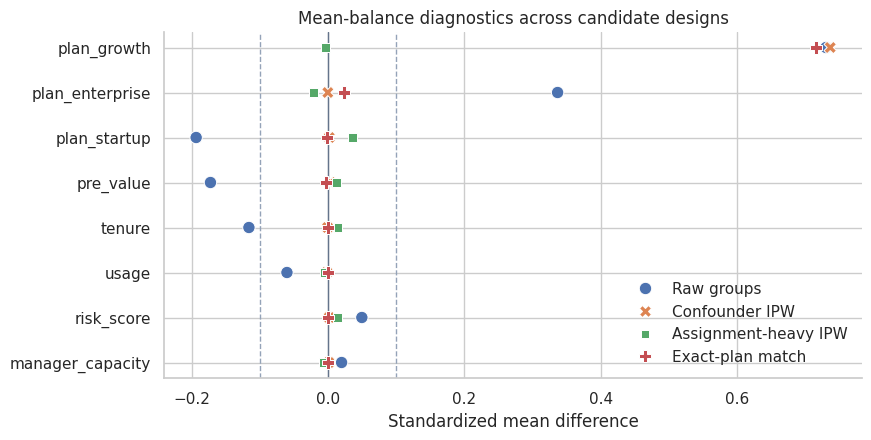

In [9]:
# Build the summary table used to connect the calculation back to the design question.
balance_tables = {
    "Raw groups": raw_balance,
    "Confounder IPW": standardized_mean_differences(balance_frame, balance_covariates, weights=df["w_ipw_confounder"]),
    "Assignment-heavy IPW": standardized_mean_differences(balance_frame, balance_covariates, weights=df["w_ipw_assignment_heavy"]),
    "Exact-plan match": standardized_mean_differences(balance_frame, balance_covariates, weights=df["w_exact_plan_match"]),
}

balance_dashboards = pd.DataFrame([
    {"design": label, **balance_dashboard(table, None if label == "Raw groups" else df[{"Confounder IPW": "w_ipw_confounder", "Assignment-heavy IPW": "w_ipw_assignment_heavy", "Exact-plan match": "w_exact_plan_match"}[label]])}
    for label, table in balance_tables.items()
])

smart_display(balance_dashboards)

plot_love(
    balance_tables,
    title="Mean-balance diagnostics across candidate designs",
)

The love plot tells a richer story than one number. The confounder IPW design balances outcome-relevant customer covariates well, but it does not balance manager capacity as much because that variable was not included. The assignment-heavy IPW design balances manager capacity too, but it tends to have more variable weights.

The professional distinction is that balance diagnostics should be interpreted through the causal graph and the assignment story, along with automatic thresholds.

## 8. Focus on Outcome-Relevant Confounders

If a variable affects treatment but not the outcome, imbalance on that variable affects precision or operational interpretation rather than confounding for the treatment effect. Imbalance on an outcome driver is more consequential.

Here we separate all-variable balance from outcome-relevant balance.

,design,max_abs_smd,mean_abs_smd,covariates_above_threshold,covariates_total
0,Raw groups,0.337,0.136,4,7
1,Confounder IPW,0.003,0.001,0,7
2,Assignment-heavy IPW,0.035,0.015,0,7
3,Exact-plan match,0.023,0.004,0,7


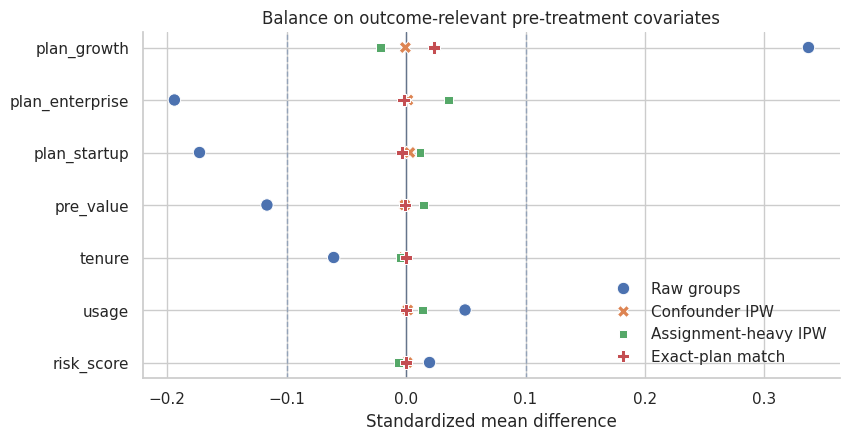

In [10]:
# Build the summary table used to connect the calculation back to the design question.
confounder_balance_tables = {
    "Raw groups": standardized_mean_differences(balance_frame, outcome_relevant_covariates),
    "Confounder IPW": standardized_mean_differences(balance_frame, outcome_relevant_covariates, weights=df["w_ipw_confounder"]),
    "Assignment-heavy IPW": standardized_mean_differences(balance_frame, outcome_relevant_covariates, weights=df["w_ipw_assignment_heavy"]),
    "Exact-plan match": standardized_mean_differences(balance_frame, outcome_relevant_covariates, weights=df["w_exact_plan_match"]),
}

confounder_dashboard = pd.DataFrame([
    {"design": label, **balance_dashboard(table)}
    for label, table in confounder_balance_tables.items()
])

smart_display(confounder_dashboard)

plot_love(
    confounder_balance_tables,
    title="Balance on outcome-relevant pre-treatment covariates",
)

This plot is often the one a causal analyst cares about most. It asks whether the variables that plausibly drive both treatment and outcome have been balanced.

The assignment-heavy design may look better on all variables, while the confounder-focused design may be sufficient for the causal question with a larger effective sample size. That tradeoff should be discussed, not buried.

## 9. Distributional Balance Beyond Means

A mean can balance while distributions differ. That matters when outcomes depend nonlinearly on a covariate or when treatment effects vary across the covariate distribution.

Two simple distributional diagnostics are:

- Weighted empirical CDF gaps.
- Quantile differences between treated and control groups.

In [11]:
# Assemble the Distributional Balance Beyond Means summary table used for interpretation.
ks_rows = []
for design, weights in {
    "Raw groups": np.ones(len(df)),
    "Confounder IPW": df["w_ipw_confounder"].to_numpy(),
    "Assignment-heavy IPW": df["w_ipw_assignment_heavy"].to_numpy(),
    "Exact-plan match": df["w_exact_plan_match"].to_numpy(),
}.items():
    for covariate in ["risk_score", "usage", "pre_value", "tenure"]:
        ks_rows.append({
            "design": design,
            "covariate": covariate,
            "weighted_ecdf_gap": weighted_ks_distance(balance_frame, covariate, weights=weights),
        })

ks_table = pd.DataFrame(ks_rows)
smart_display(ks_table.pivot(index="covariate", columns="design", values="weighted_ecdf_gap"))

design,Assignment-heavy IPW,Confounder IPW,Exact-plan match,Raw groups
covariate,,,,
pre_value,0.019,0.018,0.012,0.056
risk_score,0.026,0.012,0.025,0.131
tenure,0.032,0.022,0.024,0.087
usage,0.039,0.018,0.016,0.084


The ECDF gap is a distributional imbalance measure; lower is better. It complements SMDs by catching differences in distribution shape that mean differences can miss.

In applied work, I like to report both SMDs and at least a few distribution plots for the most important covariates.

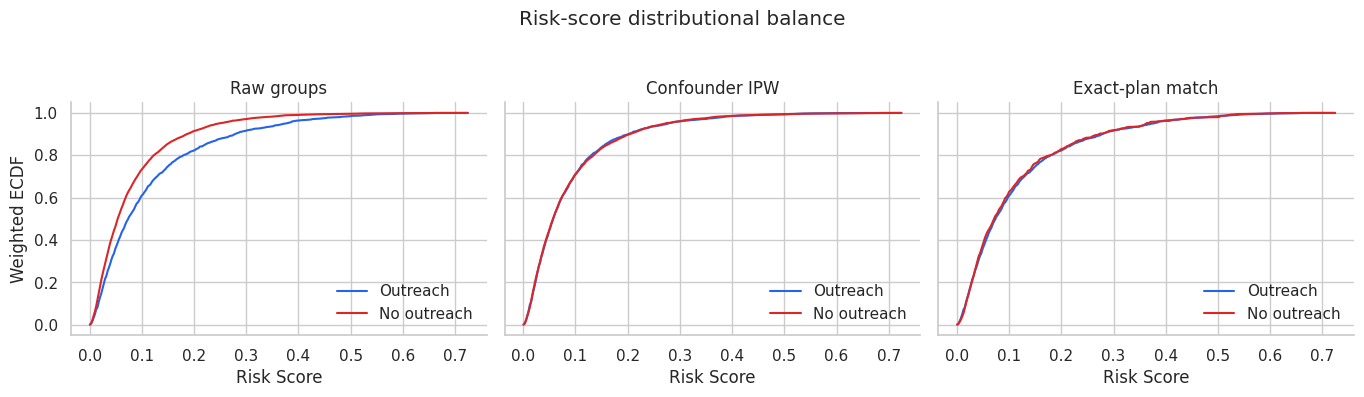

In [12]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def plot_weighted_ecdf(frame, covariate, weights_by_design, title):
    """Plot weighted empirical CDFs for treated and comparison groups.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.
        covariate: Covariate name being balanced, plotted, or summarized.
        weights_by_design: Mapping from design name to the weights used by that design.
        title: Title shown on the resulting figure.

    Returns:
        tuple: Matplotlib figure and axes for weighted ECDF comparison.
    """
    x = frame[covariate].to_numpy(dtype=float)
    grid = np.linspace(x.min(), x.max(), 300)
    fig, axes = plt.subplots(1, len(weights_by_design), figsize=(4.6 * len(weights_by_design), 3.8), sharey=True)
    if len(weights_by_design) == 1:
        axes = [axes]
    treated = frame["treated"].to_numpy() == 1
    for ax, (design, weights) in zip(axes, weights_by_design.items()):
        weights = np.asarray(weights, dtype=float)
        cdf_t = weighted_ecdf_on_grid(x[treated], weights[treated], grid)
        cdf_c = weighted_ecdf_on_grid(x[~treated], weights[~treated], grid)
        ax.plot(grid, cdf_t, label="Outreach", color="#2563eb")
        ax.plot(grid, cdf_c, label="No outreach", color="#dc2626")
        ax.set_title(design)
        ax.set_xlabel(covariate.replace("_", " ").title())
        ax.legend(frameon=False)
        sns.despine(ax=ax)
    axes[0].set_ylabel("Weighted ECDF")
    fig.suptitle(title, y=1.04)
    plt.tight_layout()
    plt.show()

plot_weighted_ecdf(
    balance_frame,
    "risk_score",
    {
        "Raw groups": np.ones(len(df)),
        "Confounder IPW": df["w_ipw_confounder"],
        "Exact-plan match": df["w_exact_plan_match"],
    },
    title="Risk-score distributional balance",
)

The ECDF plot lets you see whether one group is consistently shifted relative to the other or whether differences occur only in tails. This matters because poor tail balance can become poor counterfactual support for high-risk or low-risk accounts.

## 10. Quantile Balance

Quantile balance is a compact way to report distributional differences. Here we compare selected quantiles of `risk_score` before and after weighting.

,design,quantile,treated,control,treated_minus_control
0,Raw groups,0.10,0.017,0.014,3.386e-03
1,Raw groups,0.25,0.034,0.026,7.906e-03
2,Raw groups,0.50,0.074,0.054,2.013e-02
3,Raw groups,0.75,0.152,0.105,4.661e-02
4,Raw groups,0.90,0.280,0.186,9.303e-02
5,Confounder IPW,0.10,0.013,0.014,-7.965e-04
6,Confounder IPW,0.25,0.028,0.027,3.181e-04
7,Confounder IPW,0.50,0.057,0.057,5.832e-04
8,Confounder IPW,0.75,0.111,0.113,-2.142e-03
9,Confounder IPW,0.90,0.203,0.204,-1.523e-03


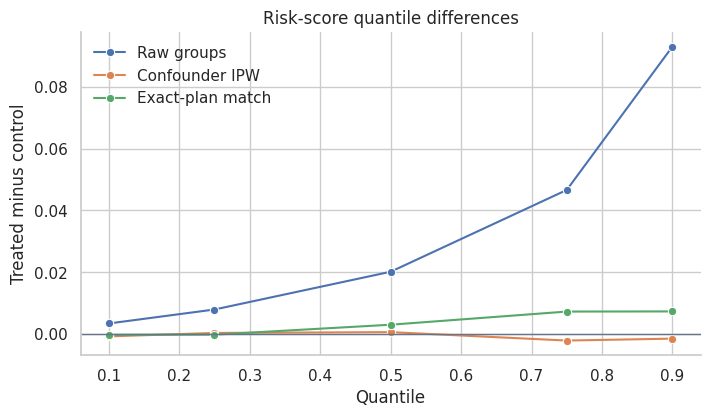

In [13]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
quantile_tables = []
for design, weights in {
    "Raw groups": np.ones(len(df)),
    "Confounder IPW": df["w_ipw_confounder"].to_numpy(),
    "Exact-plan match": df["w_exact_plan_match"].to_numpy(),
}.items():
    qt = quantile_balance(balance_frame, "risk_score", weights=weights)
    qt.insert(0, "design", design)
    quantile_tables.append(qt)

risk_quantiles = pd.concat(quantile_tables, ignore_index=True)
smart_display(risk_quantiles)

fig, ax = plt.subplots(figsize=(8, 4.2))
sns.lineplot(
    data=risk_quantiles,
    x="quantile",
    y="treated_minus_control",
    hue="design",
    marker="o",
    ax=ax,
)
ax.axhline(0, color="#64748b", linewidth=1)
ax.set_title("Risk-score quantile differences")
ax.set_xlabel("Quantile")
ax.set_ylabel("Treated minus control")
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.show()

A single mean balance number can miss whether imbalance is concentrated in the lower tail, center, or upper tail. Quantile diagnostics help identify where a design is weak.

This is especially useful in industry settings where the highest-risk or highest-value units may drive the business decision.

## 11. Higher Moments and Interactions

If the outcome depends on a nonlinear function of a covariate, balancing only the mean may not be enough. A practical diagnostic is to include transformed covariates and interactions in the balance table.

For example, if account health is nonlinear in risk, check balance on `risk_score` and `risk_score ** 2`. If high-risk high-usage customers are a distinct segment, check a risk-by-usage interaction.

,design,max_abs_smd,mean_abs_smd,covariates_above_threshold,covariates_total
0,Raw groups,0.731,0.215,9,12
1,Confounder IPW,0.737,0.063,1,12
2,Exact-plan match,0.716,0.067,1,12


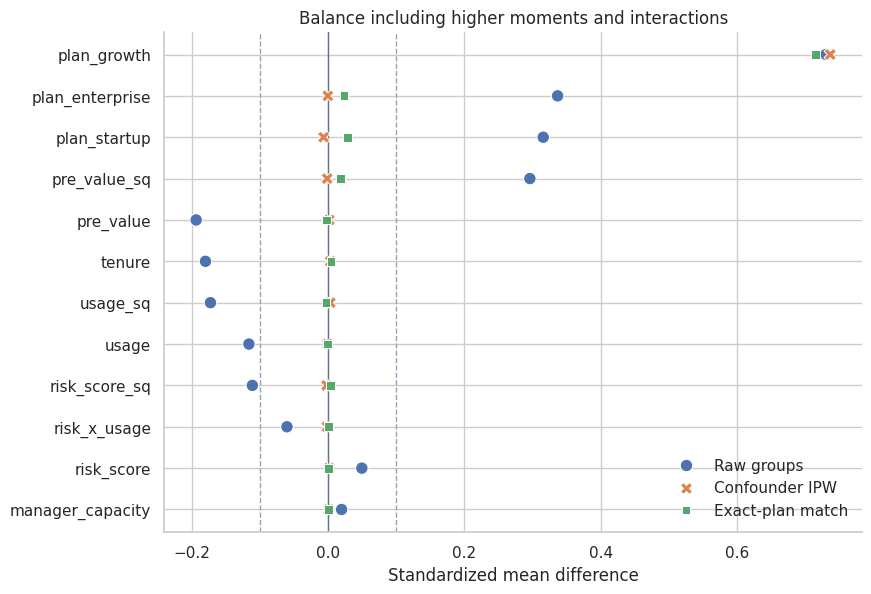

In [14]:
# Build the summary table used to connect the calculation back to the design question.
extended_balance_frame = balance_frame.copy()
extended_balance_frame["risk_score_sq"] = df["risk_score"] ** 2
extended_balance_frame["usage_sq"] = df["usage"] ** 2
extended_balance_frame["pre_value_sq"] = df["pre_value"] ** 2
extended_balance_frame["risk_x_usage"] = df["risk_score"] * df["usage"]
extended_covariates = balance_covariates + ["risk_score_sq", "usage_sq", "pre_value_sq", "risk_x_usage"]

extended_tables = {
    "Raw groups": standardized_mean_differences(extended_balance_frame, extended_covariates),
    "Confounder IPW": standardized_mean_differences(extended_balance_frame, extended_covariates, weights=df["w_ipw_confounder"]),
    "Exact-plan match": standardized_mean_differences(extended_balance_frame, extended_covariates, weights=df["w_exact_plan_match"]),
}

extended_summary = pd.DataFrame([
    {"design": label, **balance_dashboard(table)}
    for label, table in extended_tables.items()
])

smart_display(extended_summary)

plot_love(
    extended_tables,
    title="Balance including higher moments and interactions",
    figsize=(9, 6.5),
)

This is a more demanding diagnostic. A design that balances first moments may still leave imbalance in squared terms or interactions.

Do not add every possible transformation mechanically. Add transformations that matter for the outcome model, the causal graph, or the business segmentation logic.

## 12. Categorical Balance

Categorical variables are often represented as dummy indicators. SMDs on dummies are useful, but it is also helpful to inspect weighted proportions directly.

,design,group,level,weighted_share
0,Raw groups,Outreach,enterprise,0.226
1,Raw groups,Outreach,growth,0.377
2,Raw groups,Outreach,startup,0.397
3,Raw groups,No outreach,enterprise,0.206
4,Raw groups,No outreach,growth,0.367
5,Raw groups,No outreach,startup,0.427
6,Confounder IPW,Outreach,enterprise,0.211
7,Confounder IPW,Outreach,growth,0.369
8,Confounder IPW,Outreach,startup,0.420
9,Confounder IPW,No outreach,enterprise,0.210


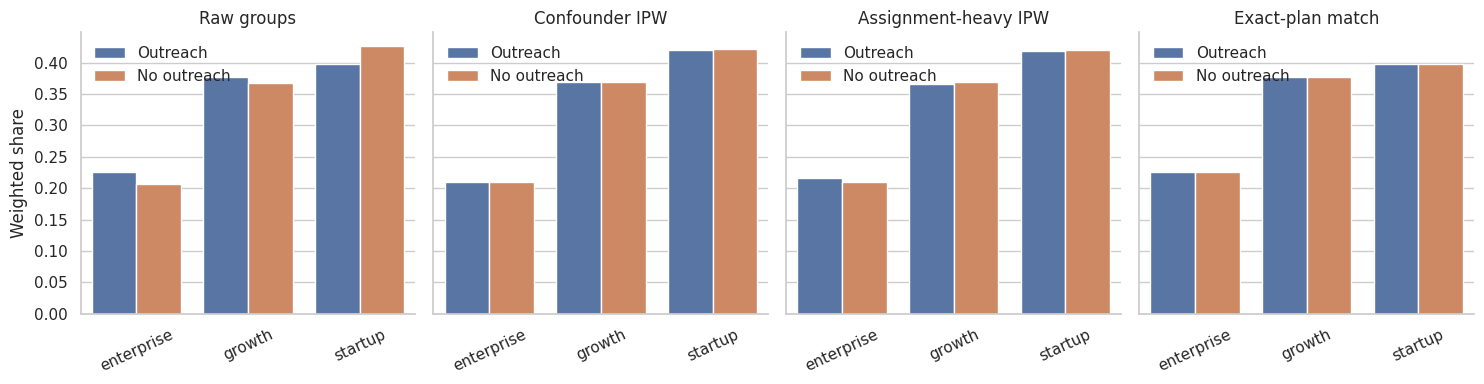

In [15]:
# Helper functions for this lecture. Docstrings state each helper's inputs, output, and causal role.
def weighted_category_table(frame, category, weights, treatment="treated"):
    """Compute weighted category shares by treatment status.

    Args:
        frame: Analysis DataFrame to copy, transform, or summarize.
        category: Categorical variable whose weighted distribution is compared.
        weights: Observation weights used to define the target pseudo-population or summary.
        treatment: Treatment indicator or treatment column name.

    Returns:
        pandas.DataFrame: Weighted category shares by treatment group.
    """
    rows = []
    for treated_value, group_name in [(1, "Outreach"), (0, "No outreach")]:
        mask = frame[treatment] == treated_value
        sub = frame.loc[mask, category]
        sub_weights = np.asarray(weights)[mask]
        total_weight = sub_weights.sum()
        for level in sorted(frame[category].unique()):
            rows.append({
                "group": group_name,
                "level": level,
                "weighted_share": sub_weights[sub == level].sum() / total_weight,
            })
    return pd.DataFrame(rows)

category_tables = []
for design, weights in {
    "Raw groups": np.ones(len(df)),
    "Confounder IPW": df["w_ipw_confounder"].to_numpy(),
    "Assignment-heavy IPW": df["w_ipw_assignment_heavy"].to_numpy(),
    "Exact-plan match": df["w_exact_plan_match"].to_numpy(),
}.items():
    table = weighted_category_table(df, "plan", weights)
    table.insert(0, "design", design)
    category_tables.append(table)

plan_balance = pd.concat(category_tables, ignore_index=True)
smart_display(plan_balance)

fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=True)
for ax, design in zip(axes, plan_balance["design"].unique()):
    sns.barplot(
        data=plan_balance[plan_balance["design"] == design],
        x="level",
        y="weighted_share",
        hue="group",
        ax=ax,
    )
    ax.set_title(design)
    ax.set_xlabel("")
    ax.set_ylabel("Weighted share" if ax is axes[0] else "")
    ax.tick_params(axis="x", rotation=25)
    ax.legend(frameon=False)
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

For categorical covariates, direct proportion plots are often easier for stakeholders than SMD tables. The SMD table is compact, but the bar plot makes the segment composition visible.

When a categorical variable is strategically important, do not rely only on a single aggregate balance score.

## 13. Score Overlap Is Not Covariate Balance

A common mistake is to inspect only the propensity-score distribution. Score overlap is important, but it does not guarantee balance on every covariate.

A design can have good-looking score overlap and still fail to balance an important variable if the score model is misspecified.

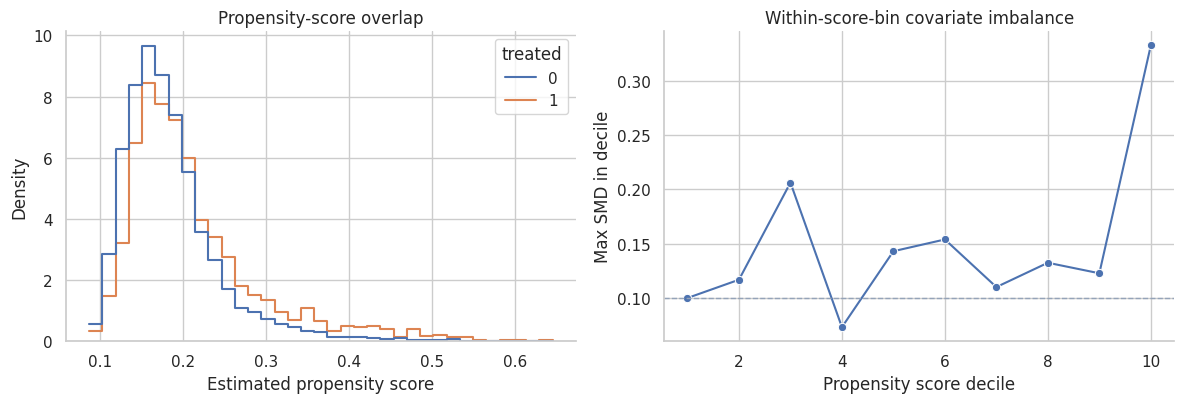

In [16]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

sns.histplot(
    data=df,
    x="ps_confounder",
    hue="treated",
    stat="density",
    common_norm=False,
    bins=35,
    element="step",
    fill=False,
    ax=axes[0],
)
axes[0].set_title("Propensity-score overlap")
axes[0].set_xlabel("Estimated propensity score")

score_bin_frame = df.copy()
score_bin_frame["score_decile"] = pd.qcut(score_bin_frame["ps_confounder"], 10, duplicates="drop")
within_decile = (
    score_bin_frame.groupby("score_decile", observed=True)
    .apply(lambda g: standardized_mean_differences(g[["treated", "risk_score", "usage", "pre_value"]], ["risk_score", "usage", "pre_value"])["abs_smd"].max())
    .reset_index(name="max_abs_smd_in_decile")
)
within_decile["decile_mid"] = np.arange(1, len(within_decile) + 1)

sns.lineplot(
    data=within_decile,
    x="decile_mid",
    y="max_abs_smd_in_decile",
    marker="o",
    ax=axes[1],
)
axes[1].axhline(0.10, color="#94a3b8", linestyle="--", linewidth=1)
axes[1].set_title("Within-score-bin covariate imbalance")
axes[1].set_xlabel("Propensity score decile")
axes[1].set_ylabel("Max SMD in decile")

for ax in axes:
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

The left panel checks overlap on the scalar score. The right panel asks whether covariates are still imbalanced within score neighborhoods.

Both matter. The score is a summary of assignment probability. Balance diagnostics test whether that summary produced the design we needed.

## 14. Weight Diagnostics as Balance Context

For weighting designs, balance and weight stability should be read together. Excellent balance created by a few enormous weights may be fragile.

,design,mean_weight,p95_weight,p99_weight,max_weight,effective_sample_size
0,Confounder IPW,1.000,1.264,1.550,2.283,7815.099
1,Assignment-heavy IPW,1.001,1.513,2.648,9.061,6908.010


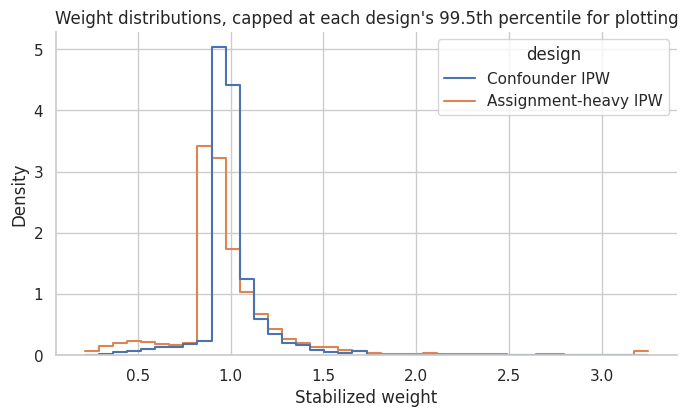

In [17]:
# Prepare the diagnostic display and label the design features that matter for interpretation.
weight_summary = pd.DataFrame([
    {
        "design": "Confounder IPW",
        "mean_weight": df["w_ipw_confounder"].mean(),
        "p95_weight": np.quantile(df["w_ipw_confounder"], 0.95),
        "p99_weight": np.quantile(df["w_ipw_confounder"], 0.99),
        "max_weight": df["w_ipw_confounder"].max(),
        "effective_sample_size": effective_sample_size(df["w_ipw_confounder"]),
    },
    {
        "design": "Assignment-heavy IPW",
        "mean_weight": df["w_ipw_assignment_heavy"].mean(),
        "p95_weight": np.quantile(df["w_ipw_assignment_heavy"], 0.95),
        "p99_weight": np.quantile(df["w_ipw_assignment_heavy"], 0.99),
        "max_weight": df["w_ipw_assignment_heavy"].max(),
        "effective_sample_size": effective_sample_size(df["w_ipw_assignment_heavy"]),
    },
])

smart_display(weight_summary)

fig, ax = plt.subplots(figsize=(8, 4.2))
plot_df = pd.DataFrame({
    "Confounder IPW": df["w_ipw_confounder"],
    "Assignment-heavy IPW": df["w_ipw_assignment_heavy"],
}).melt(var_name="design", value_name="weight")
plot_df["weight_capped_for_plot"] = plot_df.groupby("design")["weight"].transform(lambda x: np.minimum(x, x.quantile(0.995)))
sns.histplot(
    data=plot_df,
    x="weight_capped_for_plot",
    hue="design",
    stat="density",
    common_norm=False,
    bins=40,
    element="step",
    fill=False,
    ax=ax,
)
ax.set_title("Weight distributions, capped at each design's 99.5th percentile for plotting")
ax.set_xlabel("Stabilized weight")
sns.despine(ax=ax)
plt.show()

The assignment-heavy design may balance more variables, but it pays for that by giving more influence to a smaller effective sample. That might be acceptable, but it should be explicit.

Balance diagnostics should not be reduced to "all SMDs below 0.1." The design must also have enough support to make the target estimand credible.

## 15. A Design Readiness Dashboard

A practical project needs a concise readiness summary. The dashboard below combines balance and design-stability metrics.

In [18]:
# Build the summary table used to connect the calculation back to the design question.
readiness_rows = []
for label, table in confounder_balance_tables.items():
    if label == "Raw groups":
        weights = np.ones(len(df))
    elif label == "Confounder IPW":
        weights = df["w_ipw_confounder"].to_numpy()
    elif label == "Assignment-heavy IPW":
        weights = df["w_ipw_assignment_heavy"].to_numpy()
    else:
        weights = df["w_exact_plan_match"].to_numpy()
    row = {"design": label, **balance_dashboard(table, weights=weights)}
    row["ready_by_simple_rule"] = (
        row["max_abs_smd"] < 0.10
        and row["ess_share_of_n"] > 0.35
        and row["covariates_above_threshold"] == 0
    )
    readiness_rows.append(row)

readiness = pd.DataFrame(readiness_rows)
smart_display(readiness)

,design,max_abs_smd,mean_abs_smd,covariates_above_threshold,covariates_total,effective_sample_size,ess_share_of_n,max_weight,p99_weight,ready_by_simple_rule
0,Raw groups,0.337,0.136,4,7,8000.000,1.000,1.000,1.000,False
1,Confounder IPW,0.003,0.001,0,7,7815.099,0.977,2.283,1.550,True
2,Assignment-heavy IPW,0.035,0.015,0,7,6908.010,0.864,9.061,2.648,True
3,Exact-plan match,0.023,0.004,0,7,2619.025,0.327,4.000,2.000,False


A simple rule can help organize a readout, but it should not replace judgment. If one slightly imbalanced variable is causally unimportant, the design may still be acceptable. If one important confounder is near the threshold and the outcome is highly sensitive to it, the design may need revision.

The dashboard is a conversation starter, not an autopilot.

## 16. What to Do When Balance Is Poor

If a design fails balance diagnostics, do not patch the outcome model first. Revisit the design.

Common next moves:

- Add important pre-treatment confounders to the propensity model.
- Add nonlinear terms or interactions that reflect assignment rules.
- Use exact matching or calipers for strategically important variables.
- Restrict to an overlap population where comparison is credible.
- Trim units with extreme scores or weights, while reporting the target-population change.
- Use a doubly robust estimator after improving the design.
- Reframe the estimand if the original population is not supported.

Poor balance is information. It tells you where the observational comparison is weak.

## 17. Reporting Template

A professional balance section should include:

| Component | What to report |
|---|---|
| Adjustment set | Pre-treatment variables and why they matter. |
| Design candidates | Matching, weighting, trimming, or regression specifications considered. |
| Mean balance | SMD table and love plot before and after adjustment. |
| Distributional balance | ECDF, quantile, histogram, or density plots for key covariates. |
| Higher-order balance | Nonlinear terms and interactions when substantively relevant. |
| Weight or match stability | ESS, max weights, dropped units, reused controls. |
| Decision | Whether the design is ready for outcome analysis. |
| Remaining threats | Hidden confounding, measurement error, missingness, interference. |

This makes the causal analysis auditable. A reader can see how the comparison was constructed before seeing the final effect estimate.

## Key Takeaways

- Balance diagnostics evaluate the design, not the treatment effect.
- Standardized mean differences are usually better than p-values for balance reporting because they are not driven by sample size.
- Love plots provide a compact view of many covariates and designs.
- Mean balance is not enough; inspect distributions, tails, higher moments, and interactions for important covariates.
- Score overlap is necessary but not sufficient for covariate balance.
- Weight diagnostics and balance diagnostics should be interpreted together.
- Thresholds such as `0.10` are practical heuristics, not universal laws.
- If balance is poor, revise the design before interpreting outcomes.

## References

Austin, P. C. (2009). Balance diagnostics for comparing the distribution of baseline covariates between treatment groups in propensity-score matched samples. *Statistics in Medicine, 28*(25), 3083-3107. https://doi.org/10.1002/sim.3697

Austin, P. C. (2011). An introduction to propensity score methods for reducing the effects of confounding in observational studies. *Multivariate Behavioral Research, 46*(3), 399-424. https://doi.org/10.1080/00273171.2011.568786

Austin, P. C., & Stuart, E. A. (2015). Moving towards best practice when using inverse probability of treatment weighting using the propensity score to estimate causal treatment effects in observational studies. *Statistics in Medicine, 34*(28), 3661-3679. https://doi.org/10.1002/sim.6607

Li, F., Morgan, K. L., & Zaslavsky, A. M. (2017). Balancing covariates via propensity score weighting. *Journal of the American Statistical Association, 113*(521), 390-400. https://doi.org/10.1080/01621459.2016.1260466

Stuart, E. A. (2010). Matching methods for causal inference: A review and a look forward. *Statistical Science, 25*(1), 1-21. https://doi.org/10.1214/09-STS313